# IMPORTS

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import ghibtools as gh
import pingouin as pg
from scipy.stats import spearmanr, median_abs_deviation
import os

from configuration import *
from dataio import *
from utils import radar_factory, concatenate_psycho, get_mental_activities, plot_correlation_matrix
from analyse_memory import *
from anova_permutation import anova_permutation

c:\Users\marion.walter\.virtualenvs\study2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# CODE

## Article secion 3.1	No beneficial effect of rest on memory performances

### Initial retrieval analyses

Check for memory performances equivalency at initial retrieval

Note : in the following dataframe, learning order columns contains 'E1' corresponding to 'Encoding 1' or Learning 1, and 'E2' corresponding to 'Encoding 2' or Learning 2

#### get dataframe

In [ ]:
df = get_all_trials_data_with_trial_numbers()
df_grouped = df.groupby(['subject', 'condition', 'order', 'learning_order', 'phase']).agg({
    'score': 'mean'
}).reset_index()

df = df_grouped[df_grouped['phase'] == 'initial']

phase == 'E1'
phase == 'E2'
phase == 'R1'
phase == 'R2'
phase == 'RF'


#### Permuation ANOVA - condition and learning phase

In [ ]:
anova_permutation(
        data=df,
        dependent_variable='score',
        within_factors=["learning_order", 'condition'],
    random_factor="subject",
    )

R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: In Sys.setlocale("LC_ALL", "English_United States.UTF-8") :  
R callback write-console: 
   
R callback write-console:  using locale code page other than 1252 may cause problems
  


Metadata features ['order', 'phase'] are not used in the model
Mixed design detected: 'method' has been overridden and set to 'Rd_kheradPajouh_renaud'.
Model formula : score ~ learning_order * condition + Error(subject/(learning_order * condition))

Resampling test using Rd_kheradPajouh_renaud to handle nuisance variables and 5000 permutations.
                               SSn dfn    SSd dfd      MSEn    MSEd         F
learning_order           1.092e-01   1 0.3351  28 1.092e-01 0.01197 9.125e+00
condition                4.267e-04   1 0.3351  28 4.267e-04 0.01197 3.565e-02
learning_order:condition 4.930e-32   1 1.1285  28 4.930e-32 0.04030 1.223e-30
                         parametric P(>F) resampled P(>F)
learning_order                   0.005335          0.0052
condition                        0.851610          0.8486
learning_order:condition         1.000000          1.0000



{'y': {'1': 0.64,
  '3': 0.88,
  '5': 0.84,
  '7': 0.64,
  '9': 0.56,
  '11': 0.44,
  '13': 0.8,
  '15': 0.88,
  '17': 0.84,
  '19': 0.6,
  '21': 0.96,
  '23': 0.68,
  '25': 0.76,
  '27': 0.64,
  '29': 1.0,
  '31': 1.0,
  '33': 1.0,
  '35': 0.96,
  '37': 1.0,
  '39': 0.92,
  '41': 0.64,
  '43': 0.8,
  '45': 0.84,
  '47': 0.92,
  '49': 0.72,
  '51': 0.8,
  '53': 0.72,
  '55': 0.96,
  '57': 0.52,
  '59': 0.76,
  '61': 0.92,
  '63': 0.52,
  '65': 0.72,
  '67': 0.72,
  '69': 0.88,
  '71': 0.84,
  '73': 0.52,
  '75': 0.8,
  '77': 1.0,
  '79': 0.96,
  '81': 0.44,
  '83': 0.56,
  '85': 0.84,
  '87': 0.96,
  '89': 0.52,
  '91': 0.6,
  '93': 0.92,
  '95': 0.84,
  '97': 0.88,
  '99': 0.72,
  '101': 0.64,
  '103': 0.72,
  '105': 0.88,
  '107': 0.88,
  '109': 0.44,
  '111': 0.76,
  '113': 0.92,
  '115': 0.96,
  '117': 0.76,
  '119': 0.56},
 'model.matrix': array([[ 1.,  1.,  1.,  1.],
        [ 1., -1., -1.,  1.],
        [ 1., -1.,  1., -1.],
        [ 1.,  1., -1., -1.],
        [ 1.,  1.,  1., 

#### A few figures for data exploration, not used in the article

               T  dof alternative     p_val           CI95   cohen_d  \
T_test -0.088216   28   two-sided  0.930333  [-0.13, 0.12]  0.032212   

           power   BF10  
T_test  0.050833  0.345  
{'p': np.float64(0.9303327530634125), 'es': None, 'es_label': None, 'es_interp': None}


c:\Users\marion.walter\.virtualenvs\study2\Lib\site-packages\ghibtools\stats.py:411: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data = df, x = predictor, y = outcome, order = order, hue_order=[True, False], split=True, ax=ax, palette = palette, inner='box', alpha=0.2, cut=0) # construct basic ax without annotation


Text(0.5, 0.98, 'Comparison of Scores between Conditions for Learning 1')

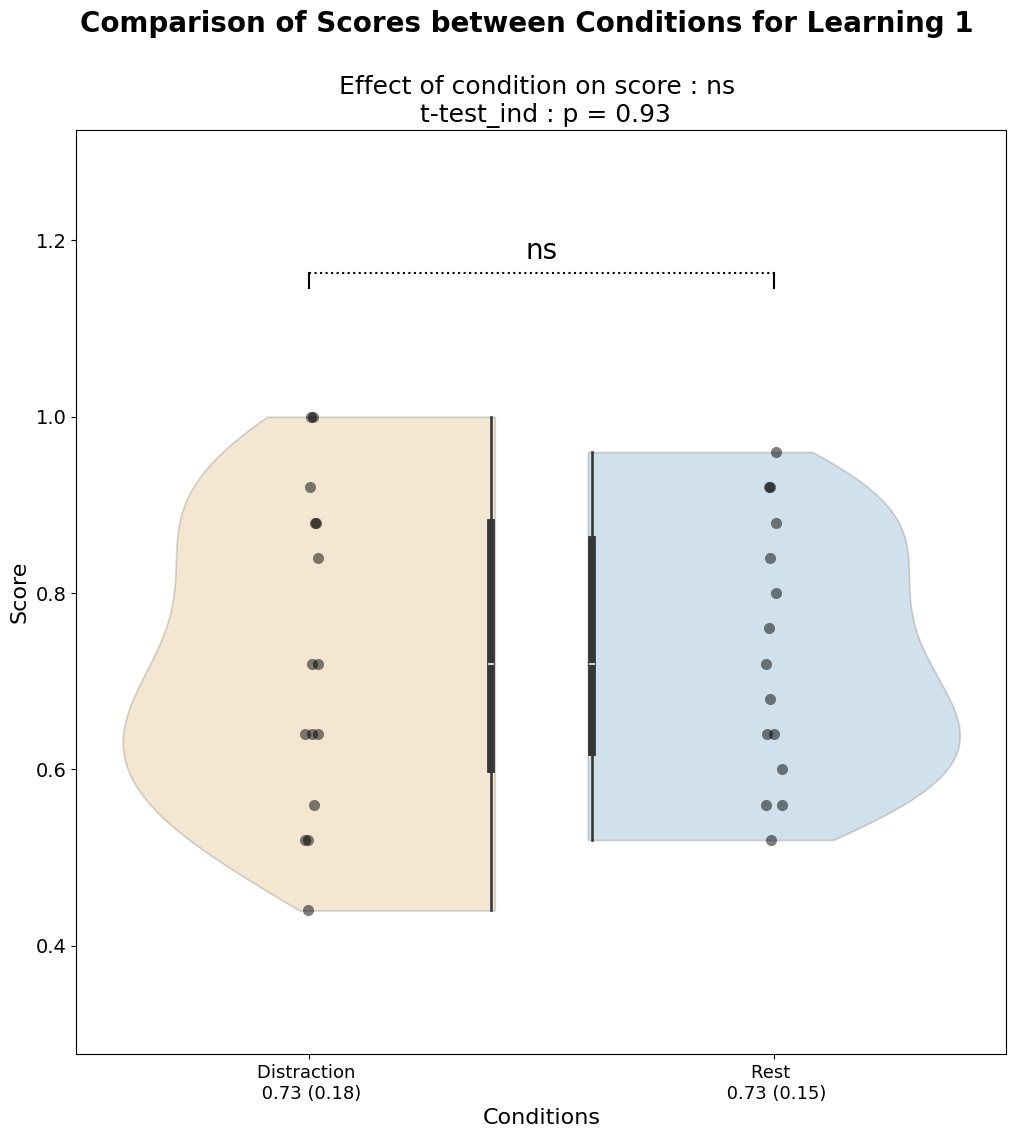

In [ ]:
sub_df = df[df['learning_order'] == 'E1']

fig, ax = plt.subplots(figsize=(12, 12))

colors = sns.color_palette('colorblind')
order = ['Rest', 'Distraction']

palette={'Rest':  colors[0], 'Distraction': colors[1]}

gh.auto_stats(sub_df, 
              outcome='score', 
              design='between',
              palette=palette,
              predictor='condition',
              return_pval=True,
              fontsize=18,
              ax=ax)

ax.tick_params(axis='y', labelsize=14)
ax.set_xlabel('Conditions')
ax.set_ylabel('Score')

fig.suptitle('Comparison of Scores between Conditions for Learning 1', fontsize=20, fontweight='bold')


               T  dof alternative     p_val           CI95   cohen_d  \
T_test  0.092634   28   two-sided  0.926854  [-0.11, 0.12]  0.033825   

           power   BF10  
T_test  0.050918  0.346  
{'p': np.float64(0.926853950850227), 'es': None, 'es_label': None, 'es_interp': None}


c:\Users\marion.walter\.virtualenvs\study2\Lib\site-packages\ghibtools\stats.py:411: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data = df, x = predictor, y = outcome, order = order, hue_order=[True, False], split=True, ax=ax, palette = palette, inner='box', alpha=0.2, cut=0) # construct basic ax without annotation


Text(0.5, 0.98, 'Comparison of Scores between Conditions for Learning 2')

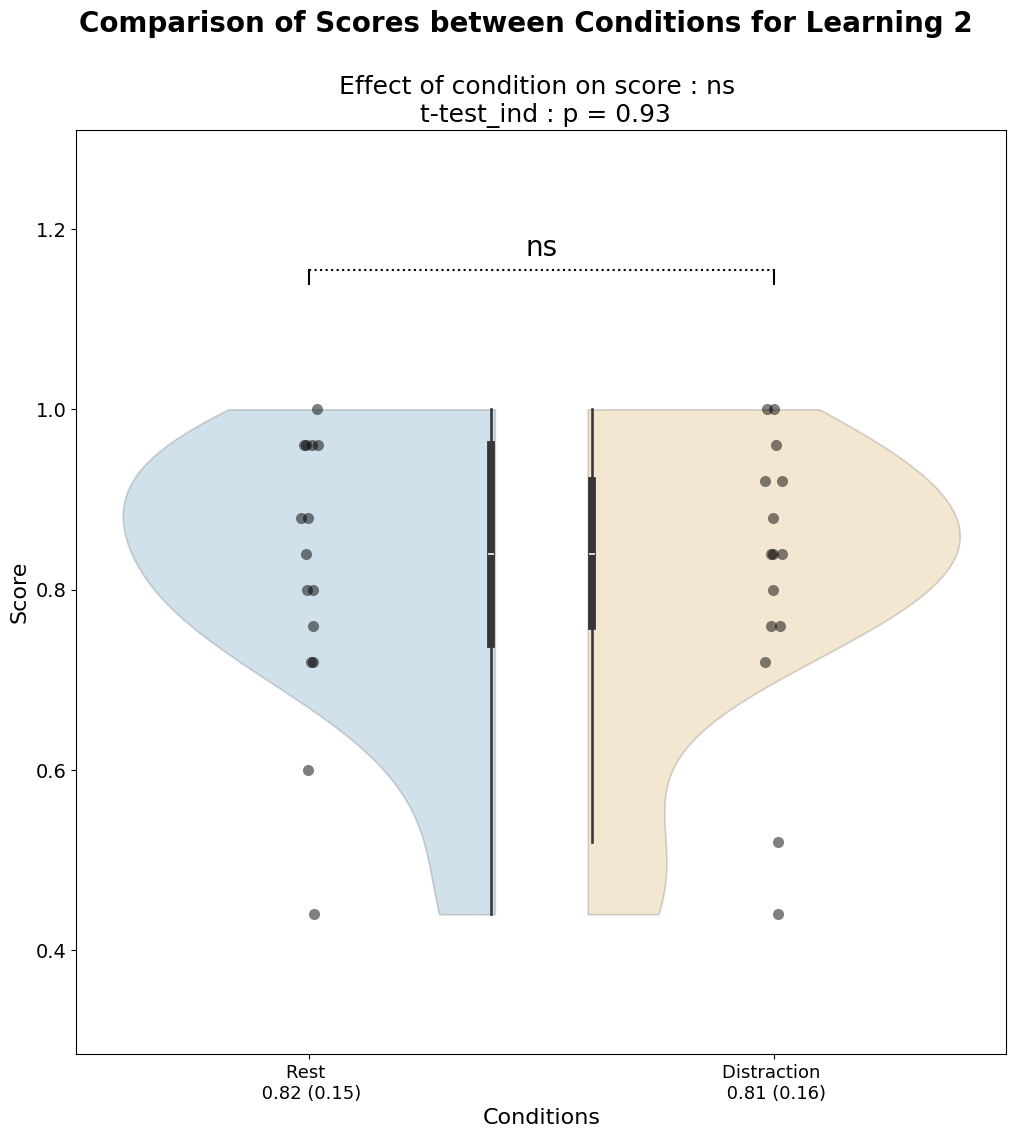

In [ ]:
sub_df = df[df['learning_order'] == 'E2']

fig, ax = plt.subplots(figsize=(12, 12))

colors = sns.color_palette('colorblind')
order = ['Rest', 'Distraction']

palette={'Rest':  colors[0], 'Distraction': colors[1]}

gh.auto_stats(sub_df, 
              outcome='score', 
              design='between',
              palette=palette,
              predictor='condition',
              return_pval=True,
              fontsize=18,
              ax=ax)

ax.tick_params(axis='y', labelsize=14)
ax.set_xlabel('Conditions')
ax.set_ylabel('Score')

fig.suptitle('Comparison of Scores between Conditions for Learning 2', fontsize=20, fontweight='bold')


          W_val alternative     p_val       RBC      CLES
Wilcoxon   83.0   two-sided  0.011163 -0.560847  0.346111
{'p': np.float64(0.011162553342003936), 'es': np.float64(0.3461111111111111), 'es_label': 'CLES', 'es_interp': 'S'}


Text(0.5, 0.98, 'Score at Initial Recall for both Learning Phases')

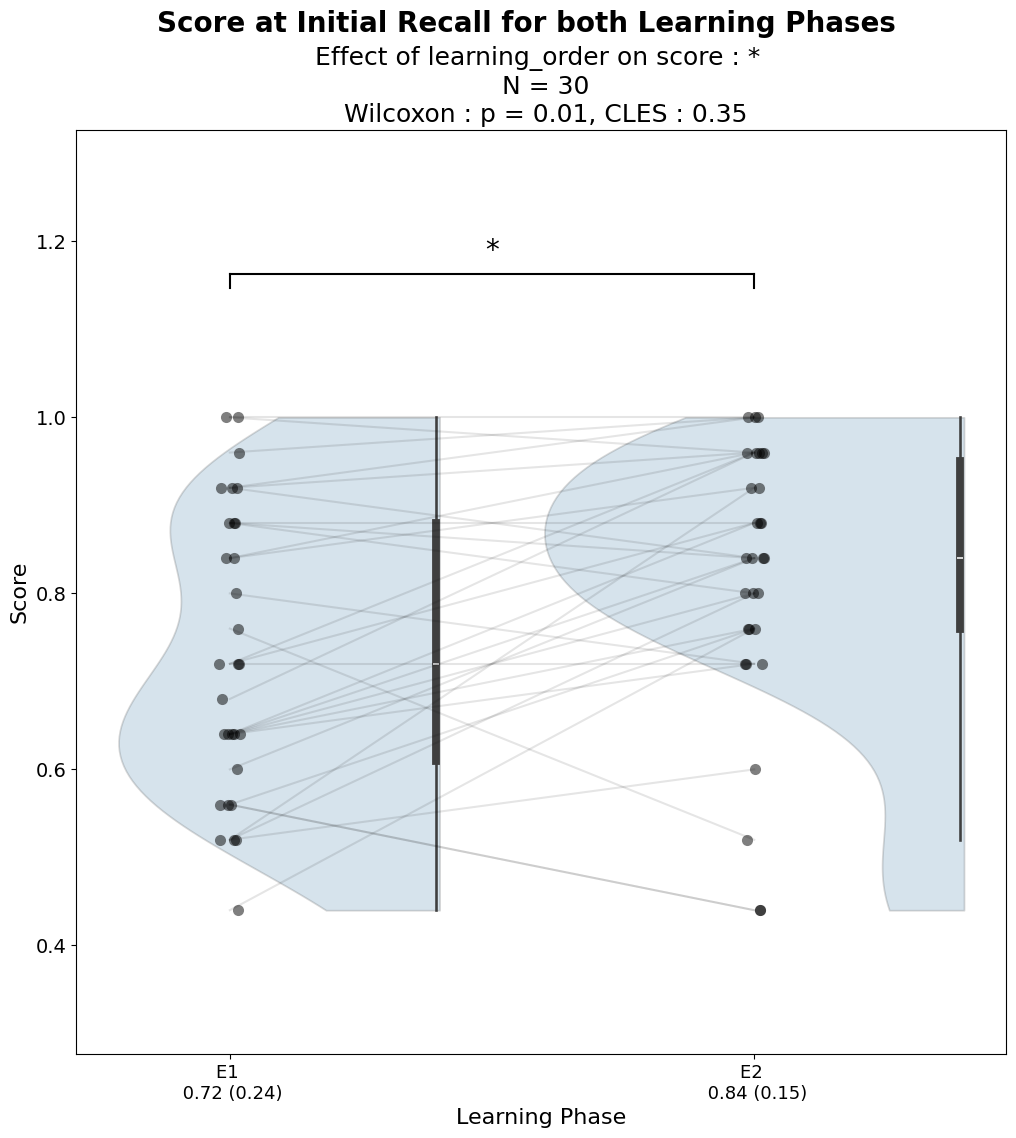

In [ ]:
fig, ax = plt.subplots(figsize=(12, 12))

colors = sns.color_palette('colorblind')
order = ['Rest', 'Distraction']

palette={'Rest':  colors[0], 'Distraction': colors[1]}

gh.auto_stats(df, 
              outcome='score', 
              design='within',
              subject='subject',
              predictor='learning_order',
              return_pval=True,
              fontsize=18,
              ax=ax)

ax.tick_params(axis='y', labelsize=14)
ax.set_xlabel('Learning Phase')
ax.set_ylabel('Score')

fig.suptitle('Score at Initial Recall for both Learning Phases', fontsize=20, fontweight='bold')


               T  dof alternative     p_val           CI95   cohen_d  \
T_test -1.260278   14   two-sided  0.228171  [-0.23, 0.06]  0.565087   

           power   BF10  
T_test  0.530926  0.512  
{'p': np.float64(0.22817098462984825), 'es': None, 'es_label': None, 'es_interp': None}


Text(0.5, 0.98, 'Score at Initial Retrieval for both Rest conditions')

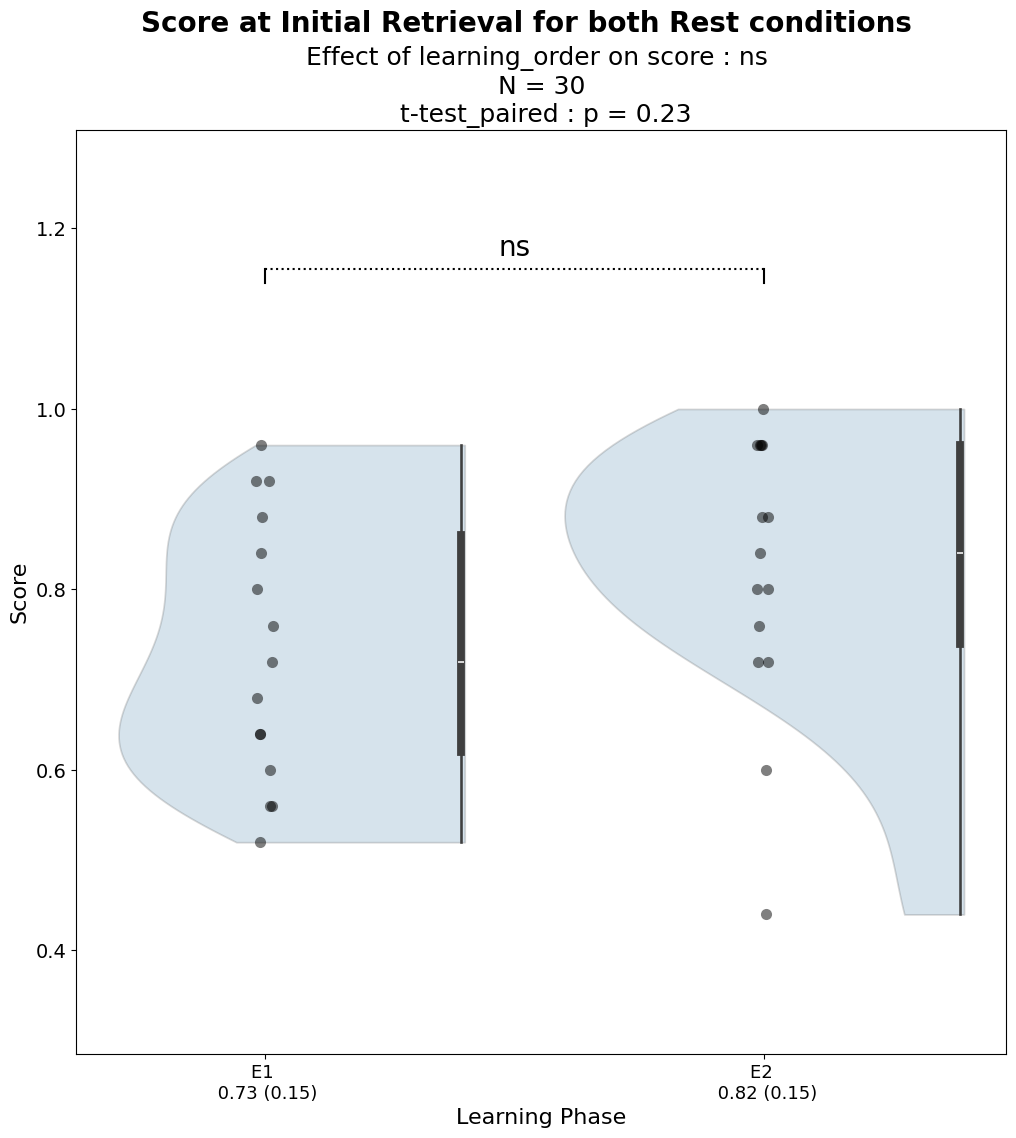

In [ ]:
sub_df = df[df['condition'] == 'Rest']

fig, ax = plt.subplots(figsize=(12, 12))

colors = sns.color_palette('colorblind')
order = ['E1', 'E2']

palette={'E1':  colors[0], 'E2': colors[1]}

gh.auto_stats(sub_df, 
              outcome='score', 
              design='within',
              subject='subject',
              # palette=palette,
              predictor='learning_order',
              order=order,
              return_pval=True,
              fontsize=18,
              ax=ax)

ax.tick_params(axis='y', labelsize=14)
ax.set_xlabel('Learning Phase')
ax.set_ylabel('Score')

fig.suptitle('Score at Initial Retrieval for both Rest conditions', fontsize=20, fontweight='bold')

               T  dof alternative     p_val          CI95   cohen_d     power  \
T_test -1.538583   14   two-sided  0.146197  [-0.2, 0.03]  0.497079  0.433794   

         BF10  
T_test  0.693  
{'p': np.float64(0.14619738433448104), 'es': None, 'es_label': None, 'es_interp': None}


c:\Users\marion.walter\.virtualenvs\study2\Lib\site-packages\ghibtools\stats.py:411: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data = df, x = predictor, y = outcome, order = order, hue_order=[True, False], split=True, ax=ax, palette = palette, inner='box', alpha=0.2, cut=0) # construct basic ax without annotation


Text(0.5, 0.98, 'Score at Initial Retrieval for both Distraction conditions')

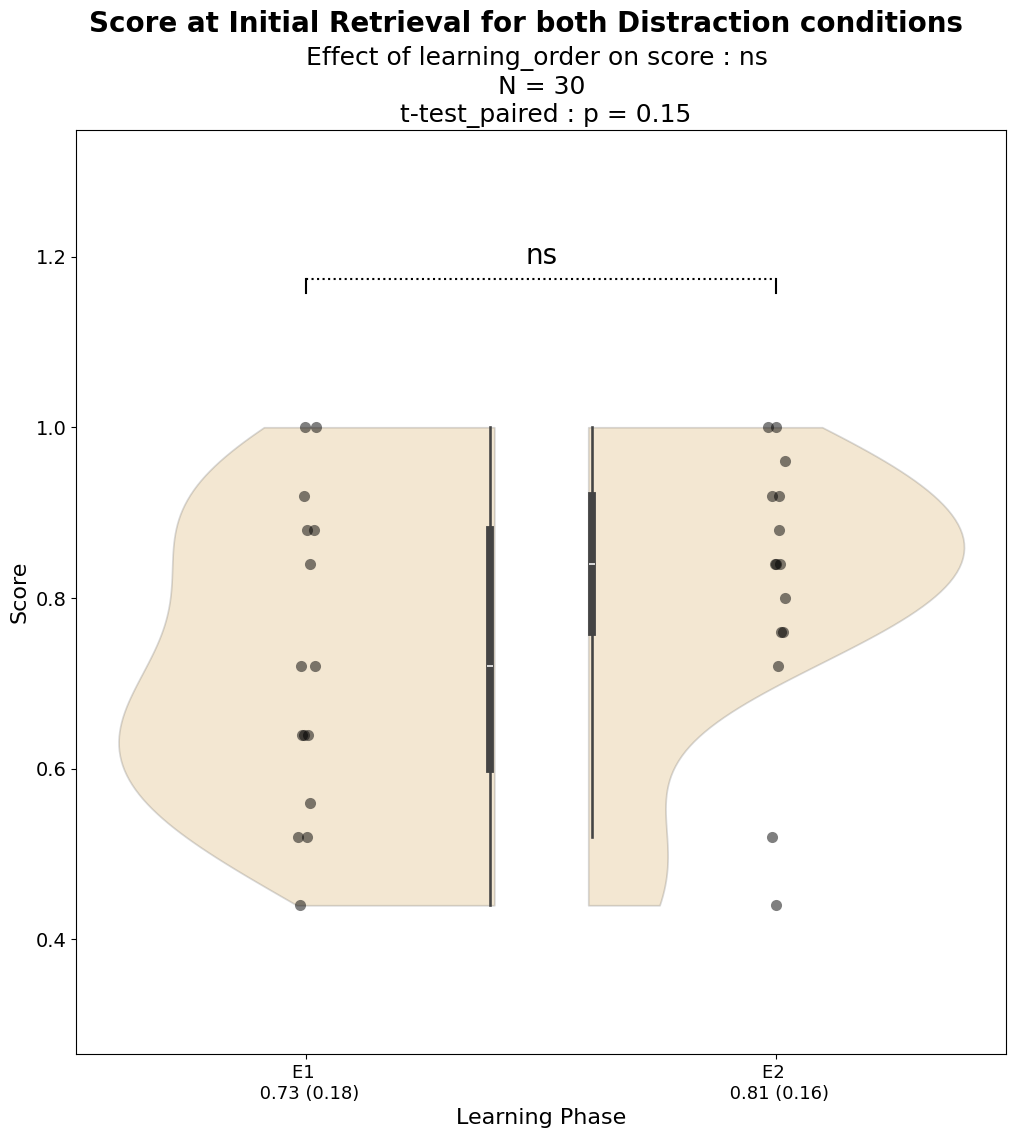

In [ ]:
sub_df = df[df['condition'] == 'Distraction']

fig, ax = plt.subplots(figsize=(12, 12))

colors = sns.color_palette('colorblind')
order = ['E1', 'E2']

palette={'E1':  colors[1], 'E2': colors[1]}

gh.auto_stats(sub_df, 
              outcome='score', 
              design='within',
              subject='subject',
              palette=palette,
              predictor='learning_order',
              order=order,
              return_pval=True,
              fontsize=18,
              ax=ax)

ax.tick_params(axis='y', labelsize=14)
ax.set_xlabel('Learning Phase')
ax.set_ylabel('Score')

fig.suptitle('Score at Initial Retrieval for both Distraction conditions', fontsize=20, fontweight='bold')

## Article section 3.3	Relationship between memory performances, Daydreaming Frequency and mental activities

Compute median and mad for each mental activity in each condition

In [ ]:
mental_activities = get_mental_activities()
order = get_one_metadata_info('order')
df = mental_activities.merge(order, on=['subject'])
df

,subject,Thinking about past/future,Thinking about memory task,Meditate,Sleeping,Thinking about what I was doing (resting / task),Mind blank,Other,condition,order
0,sub-01,60.1,0.0,0.0,0.0,11.3,28.6,0.0,Rest,D-R
1,sub-07,34.2,3.9,0.0,0.0,14.5,7.9,39.5,Rest,R-D
2,sub-10,41.7,4.8,17.9,0.0,17.8,17.8,0.0,Rest,D-R
3,sub-12,33.0,9.0,29.0,0.0,14.0,9.0,6.0,Rest,R-D
4,sub-14,46.9,0.0,0.0,0.0,6.3,0.0,46.8,Rest,R-D
5,sub-16,22.2,0.0,0.0,11.1,28.3,16.2,22.2,Rest,R-D
6,sub-19,20.0,0.8,11.7,0.0,12.5,27.5,27.5,Rest,R-D
7,sub-20,11.5,23.0,9.4,6.5,12.2,7.9,29.5,Rest,D-R
8,sub-22,22.4,0.0,10.4,1.0,17.0,10.4,38.8,Rest,D-R
9,sub-23,0.6,0.7,55.5,1.3,32.9,9.0,0.0,Rest,R-D


In [ ]:
from scipy import stats

cols = ['Thinking about past/future', 'Thinking about memory task',
       'Meditate', 'Sleeping',
       'Thinking about what I was doing (resting / task)', 'Mind blank',
       'Other']

df_rest = df[df['condition'] == 'Rest']
df_dist = df[df['condition'] == 'Distraction']

for col in cols:
    median_rest = np.round(df_rest[col].median(), 2)
    mad_rest = np.round(stats.median_abs_deviation(df_rest[col], scale='normal'), 2)

    median_dist = np.round(df_dist[col].median(), 2)
    mad_dist = np.round(stats.median_abs_deviation(df_dist[col], scale='normal'), 2)
    
    print(f'{col} in Rest: median: {median_rest}, mad: {mad_rest}')
    print(f'{col} in Distraction: median: {median_dist}, mad: {mad_dist}')
    print()

Thinking about past/future in Rest: median: 33.6, mad: 19.87
Thinking about past/future in Distraction: median: 4.7, mad: 6.97

Thinking about memory task in Rest: median: 1.0, mad: 1.48
Thinking about memory task in Distraction: median: 0.0, mad: 0.0

Meditate in Rest: median: 5.45, mad: 8.08
Meditate in Distraction: median: 0.0, mad: 0.0

Sleeping in Rest: median: 1.15, mad: 1.7
Sleeping in Distraction: median: 0.0, mad: 0.0

Thinking about what I was doing (resting / task) in Rest: median: 14.25, mad: 8.97
Thinking about what I was doing (resting / task) in Distraction: median: 65.65, mad: 20.53

Mind blank in Rest: median: 7.9, mad: 11.71
Mind blank in Distraction: median: 10.55, mad: 7.93

Other in Rest: median: 5.8, mad: 8.6
Other in Distraction: median: 0.0, mad: 0.0



## Article section 3.4	Order effect

Global Memory Change (GMC) = ((score at final recall - score at initial recall)/(score at initial recall))*100).

#### get dataframe

In [ ]:
df = get_all_trials_data_with_trial_numbers()
df_GMC = compute_global_memory_change(df)
df_GMC

phase == 'E1'
phase == 'E2'
phase == 'R1'
phase == 'R2'
phase == 'RF'


,subject,condition,GMC,order
0,sub-01,Distraction,6.250000,D-R
1,sub-01,Rest,4.545455,D-R
2,sub-07,Rest,-6.250000,R-D
3,sub-07,Distraction,4.761905,R-D
4,sub-10,Distraction,-21.428571,D-R
5,sub-10,Rest,9.090909,D-R
6,sub-12,Rest,-9.090909,R-D
7,sub-12,Distraction,-5.000000,R-D
8,sub-14,Rest,6.666667,R-D
9,sub-14,Distraction,0.000000,R-D


### permutation ANOVA - order effect

In [ ]:
anova_permutation(
        data=df_GMC,
        dependent_variable='GMC',
        between_factors=["order"],
        within_factors=["condition"],
    random_factor="subject",
    )

R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: In Sys.setlocale("LC_ALL", "English_United States.UTF-8") :  
R callback write-console: 
   
R callback write-console:  using locale code page other than 1252 may cause problems
  


Mixed design detected: 'method' has been overridden and set to 'Rd_kheradPajouh_renaud'.
Model formula : GMC ~ order * condition + Error(subject/(condition))

Resampling test using Rd_kheradPajouh_renaud to handle nuisance variables and 5000 permutations.
                  SSn dfn  SSd dfd  MSEn  MSEd      F parametric P(>F)
order           249.5   1 4820  28 249.5 172.1 1.4495          0.23869
condition        41.4   1 3335  28  41.4 119.1 0.3476          0.56023
order:condition 389.5   1 3335  28 389.5 119.1 3.2695          0.08133
                resampled P(>F)
order                    0.2472
condition                0.5782
order:condition          0.0828



{'y': {'0': 6.250000000000005,
  '1': 4.545454545454549,
  '2': -6.250000000000005,
  '3': 4.761904761904766,
  '4': -21.428571428571434,
  '5': 9.090909090909086,
  '6': -9.090909090909086,
  '7': -5.000000000000004,
  '8': 6.666666666666673,
  '9': 0.0,
  '10': 5.8823529411764595,
  '11': -4.166666666666659,
  '12': -12.499999999999993,
  '13': 10.52631578947368,
  '14': 0.0,
  '15': 0.0,
  '16': 0.0,
  '17': 0.0,
  '18': 0.0,
  '19': 0.0,
  '20': 0.0,
  '21': 4.99999999999999,
  '22': -13.043478260869565,
  '23': -4.761904761904753,
  '24': -40.00000000000001,
  '25': -27.777777777777775,
  '26': -5.555555555555546,
  '27': 0.0,
  '28': -21.052631578947373,
  '29': 7.692307692307699,
  '30': -7.692307692307699,
  '31': -4.347826086956525,
  '32': -5.555555555555546,
  '33': 0.0,
  '34': 0.0,
  '35': -4.761904761904753,
  '36': -7.692307692307699,
  '37': -10.000000000000009,
  '38': 0.0,
  '39': 0.0,
  '40': -50.0,
  '41': -18.181818181818183,
  '42': -9.523809523809518,
  '43': 4.1